In [31]:
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filtering the Plants UniRef90 Data for Prevalence

In [32]:
def column_stats(df, column_name, n=None):
    if n is None:
        n = df.shape[0]
    count_column_name = column_name + "_count"
    count_df = pd.DataFrame(df[column_name].value_counts()).reset_index() 
    
    count_df.columns=[column_name, count_column_name] 
    
    count_df[column_name + "_percent"] = count_df[count_column_name].apply(lambda x: int(x)/n*100)
    print(f"Number of unique values = {len(df[column_name].unique())}")
    print(f"{count_df}")
    return count_df 


def filter_with_threshold_percentage(df, column_name, threshold, n=None):
    print(f"Size of df = {df.shape}")
    if n is None:
        n = df.shape[0]
    print(f"n= {n}")
    count_df = column_stats(df, column_name, n=n)
    
    percent_column_name = column_name + "_percent"
    
    filtered_count_df = count_df[count_df[percent_column_name] >= threshold]
    
    filtered_df = df[df[column_name].isin(list(filtered_count_df[column_name].values))]
    
    print(f"Size of filtered df = {filtered_df.shape}")
    column_stats(filtered_df, column_name, n=n)
    return filtered_df

    #Filters dataframe to include rows where value appears at least 'threshold' amount of times
def filter_with_threshold_count(df, column_name, threshold, n=None):
    print(f"Size of df = {df.shape}") 
    n = df.shape[0] 
    count_df = column_stats(df, column_name, n=n) 
    count_column_name = column_name + "_count"
    filtered_count_df = count_df[count_df[count_column_name] >= threshold] 
    
    filtered_df = df[df[column_name].isin(list(filtered_count_df[column_name].values))]
    
    print(f"Size of filtered df = {filtered_df.shape}")
    column_stats(filtered_df, column_name, n=n) 
    return filtered_df


def print_seq_len_histogram(df, n_bins):
    sns.histplot(df["seq_len"])
    
    print(f"min seq len = {min(df['seq_len'])}")
    print(f"max seq len = {max(df['seq_len'])}")
    plt.show()
    
    freq, bins = np.histogram(df["seq_len"], bins=n_bins)
    n = df.shape[0]
    hist_map = [] 
    for i in range(n_bins):
        hist_map.append({"start": bins[i], "end":bins[i+1], "count": freq[i], "percentage": freq[i]/n*100})
    hist_df = pd.DataFrame(hist_map)
    print(hist_df) 

In [33]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/input/uniref90/uniref90_viridae_embl_hosts_pruned_metadata_species_plants_w_seq.csv")
df = pd.read_csv(file_path)
df

,uniref90_id,tax_id,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq
0,UniRef90_Q8B320,219596,AUZ62356.1,['Malvastrum coromandelianum'],Malvastrum coromandelianum,Tobacco curly shoot betasatellite,species,108453,species,MTIKYNNKKGMEFIVDVKLKEDNSIVVQIELISTKSPALAKRKYII...
1,UniRef90_A0A023HRI2,12167,AGQ16883.1,['Solanum tuberosum'],Solanum tuberosum,Potato virus M,species,4113,species,MGDSTKKAETAKDVGTSQEKREARPLPTAAEFEDDDNPGNVNVREA...
2,UniRef90_Q8B333,12224,CAD37266.1,['Saccharum hybrid cultivar'],Saccharum hybrid cultivar,Sugarcane mosaic virus,species,128810,species,DAGAQGGGGNAGTQPPATGAAAQGGAQPPTTGAAAQPPATQGSQPP...
3,UniRef90_A0A023I4L6,47985,AGT29895.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 1,species,29760,species,SLRPSRPSTGQRSGDSEVARREMGDKLKRTFNIAEIFTNPEMNIIF...
4,UniRef90_Q8B337,12224,CAD37262.1,['Saccharum hybrid cultivar'],Saccharum hybrid cultivar,Sugarcane mosaic virus,species,128810,species,DAGAQGGGGNAGTQPPATGAAAQGGAQPPATGAAAQPPAAQPTGGA...
...,...,...,...,...,...,...,...,...,...,...
7266,UniRef90_L0APS0,1264880,AFZ77097.1,['Sida ciliaris'],Sida ciliaris,Sida ciliaris golden mosaic virus,species,108361,species,MYIIRNKRGSSSTQRRYYPRNSVSNRSTISRRHDFKRRAGYGSKPT...
7267,UniRef90_L0AQM1,1264880,AFZ77095.1,['Sida ciliaris'],Sida ciliaris,Sida ciliaris golden mosaic virus,species,108361,species,MKMVSLISMYLSSSRANTGARIADSSIWSPQPGQHISIQTYRELNP...
7268,UniRef90_L0ARA2,1264880,AFZ77093.1,['Sida ciliaris'],Sida ciliaris,Sida ciliaris golden mosaic virus,species,108361,species,MRSSSPSQPPSIKKAHRRAKRRAIRRRRIDLQCGCSIYFHIDCTGH...
7269,UniRef90_A0A146KUN7,12305,CEO86970.1,['Citrullus lanatus'],Citrullus lanatus,Cucumber mosaic virus,species,3654,species,RPRRGSRSAPSSADANFRVLSQQLSRLNKTLAAGRPTINHPTFVGS...


In [34]:
column_stats(df[df["virus_taxon_rank"] == "species"],"virus_name")
#1703 unique viruses

Number of unique values = 1703
                                virus_name  virus_name_count  \
0                         uncultured virus               112   
1                           Potato virus Y               101   
2                    Papaya ringspot virus                86   
3            Tomato yellow leaf curl virus                84   
4                Cacao swollen shoot virus                82   
...                                    ...               ...   
1698  Tomato yellow leaf curl Malaga virus                 1   
1699   Plant associated virga-like virus 1                 1   
1700  Tomato associated virga-like virus 1                 1   
1701            Pea associated mitovirus 1                 1   
1702  Eupatorium yellow vein betasatellite                 1   

      virus_name_percent  
0               1.540366  
1               1.389080  
2               1.182781  
3               1.155274  
4               1.127768  
...                  ...  
1698       

,virus_name,virus_name_count,virus_name_percent
0,uncultured virus,112,1.540366
1,Potato virus Y,101,1.389080
2,Papaya ringspot virus,86,1.182781
3,Tomato yellow leaf curl virus,84,1.155274
4,Cacao swollen shoot virus,82,1.127768
...,...,...,...
1698,Tomato yellow leaf curl Malaga virus,1,0.013753
1699,Plant associated virga-like virus 1,1,0.013753
1700,Tomato associated virga-like virus 1,1,0.013753
1701,Pea associated mitovirus 1,1,0.013753


In [35]:
column_stats(df[df["virus_taxon_rank"] == "species"], "virus_host_name")
#911 unique hosts

Number of unique values = 911
              virus_host_name  virus_host_name_count  virus_host_name_percent
0              Allium sativum                    336                 4.621098
1              Vitis vinifera                    288                 3.960941
2        Solanum lycopersicum                    277                 3.809655
3                Prunus avium                    156                 2.145510
4           Solanum tuberosum                    141                 1.939211
..                        ...                    ...                      ...
906           Lupinus pilosus                      1                 0.013753
907        Kennedia prostrata                      1                 0.013753
908  Xanthosoma sagittifolium                      1                 0.013753
909            Prunus spinosa                      1                 0.013753
910             Iris tectorum                      1                 0.013753

[911 rows x 3 columns]


,virus_host_name,virus_host_name_count,virus_host_name_percent
0,Allium sativum,336,4.621098
1,Vitis vinifera,288,3.960941
2,Solanum lycopersicum,277,3.809655
3,Prunus avium,156,2.145510
4,Solanum tuberosum,141,1.939211
...,...,...,...
906,Lupinus pilosus,1,0.013753
907,Kennedia prostrata,1,0.013753
908,Xanthosoma sagittifolium,1,0.013753
909,Prunus spinosa,1,0.013753


In [36]:
df["seq_len"] = df["seq"].apply(lambda x: len(x))
df = df[~df.duplicated()]
df

,uniref90_id,tax_id,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len
0,UniRef90_Q8B320,219596,AUZ62356.1,['Malvastrum coromandelianum'],Malvastrum coromandelianum,Tobacco curly shoot betasatellite,species,108453,species,MTIKYNNKKGMEFIVDVKLKEDNSIVVQIELISTKSPALAKRKYII...,118
1,UniRef90_A0A023HRI2,12167,AGQ16883.1,['Solanum tuberosum'],Solanum tuberosum,Potato virus M,species,4113,species,MGDSTKKAETAKDVGTSQEKREARPLPTAAEFEDDDNPGNVNVREA...,304
2,UniRef90_Q8B333,12224,CAD37266.1,['Saccharum hybrid cultivar'],Saccharum hybrid cultivar,Sugarcane mosaic virus,species,128810,species,DAGAQGGGGNAGTQPPATGAAAQGGAQPPTTGAAAQPPATQGSQPP...,284
3,UniRef90_A0A023I4L6,47985,AGT29895.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 1,species,29760,species,SLRPSRPSTGQRSGDSEVARREMGDKLKRTFNIAEIFTNPEMNIIF...,80
4,UniRef90_Q8B337,12224,CAD37262.1,['Saccharum hybrid cultivar'],Saccharum hybrid cultivar,Sugarcane mosaic virus,species,128810,species,DAGAQGGGGNAGTQPPATGAAAQGGAQPPATGAAAQPPAAQPTGGA...,280
...,...,...,...,...,...,...,...,...,...,...,...
7266,UniRef90_L0APS0,1264880,AFZ77097.1,['Sida ciliaris'],Sida ciliaris,Sida ciliaris golden mosaic virus,species,108361,species,MYIIRNKRGSSSTQRRYYPRNSVSNRSTISRRHDFKRRAGYGSKPT...,256
7267,UniRef90_L0AQM1,1264880,AFZ77095.1,['Sida ciliaris'],Sida ciliaris,Sida ciliaris golden mosaic virus,species,108361,species,MKMVSLISMYLSSSRANTGARIADSSIWSPQPGQHISIQTYRELNP...,87
7268,UniRef90_L0ARA2,1264880,AFZ77093.1,['Sida ciliaris'],Sida ciliaris,Sida ciliaris golden mosaic virus,species,108361,species,MRSSSPSQPPSIKKAHRRAKRRAIRRRRIDLQCGCSIYFHIDCTGH...,129
7269,UniRef90_A0A146KUN7,12305,CEO86970.1,['Citrullus lanatus'],Citrullus lanatus,Cucumber mosaic virus,species,3654,species,RPRRGSRSAPSSADANFRVLSQQLSRLNKTLAAGRPTINHPTFVGS...,193


min seq len = 11
max seq len = 7803


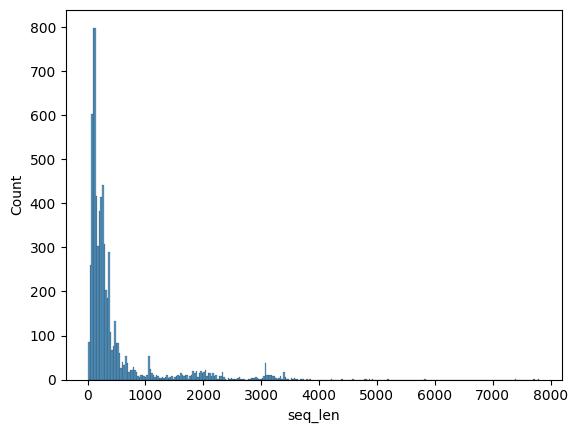

          start          end  count  percentage
0     11.000000   660.333333   6223   85.586577
1    660.333333  1309.666667    391    5.377527
2   1309.666667  1959.000000    229    3.149498
3   1959.000000  2608.333333    207    2.846926
4   2608.333333  3257.666667    146    2.007977
5   3257.666667  3907.000000     61    0.838949
6   3907.000000  4556.333333      2    0.027507
7   4556.333333  5205.666667      8    0.110026
8   5205.666667  5855.000000      1    0.013753
9   5855.000000  6504.333333      0    0.000000
10  6504.333333  7153.666667      0    0.000000
11  7153.666667  7803.000000      3    0.041260


In [37]:
print_seq_len_histogram(df, 12)

In [46]:
prev = filter_with_threshold_percentage(df, "virus_host_name", 2)

Size of df = (7271, 11)
n= 7271
Number of unique values = 911
              virus_host_name  virus_host_name_count  virus_host_name_percent
0              Allium sativum                    336                 4.621098
1              Vitis vinifera                    288                 3.960941
2        Solanum lycopersicum                    277                 3.809655
3                Prunus avium                    156                 2.145510
4           Solanum tuberosum                    141                 1.939211
..                        ...                    ...                      ...
906           Lupinus pilosus                      1                 0.013753
907        Kennedia prostrata                      1                 0.013753
908  Xanthosoma sagittifolium                      1                 0.013753
909            Prunus spinosa                      1                 0.013753
910             Iris tectorum                      1                 0.013753

[

<b> With a two percent prevalence filtering, we have four top hosts </b>:
- allium satvium (garlic)
- vitis vinifera (grapevine)
- solanum lycopersicum (tomato)
- prunus avium (sweet cherry)

In [47]:
output_file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref90/uniref90_two_percent.csv")
prev.to_csv(output_file_path, index=False)
prev

,uniref90_id,tax_id,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len
3,UniRef90_A0A023I4L6,47985,AGT29895.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 1,species,29760,species,SLRPSRPSTGQRSGDSEVARREMGDKLKRTFNIAEIFTNPEMNIIF...,80
45,UniRef90_A0A159KI68,47985,AMD11618.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 1,species,29760,species,PAEYNSFKRSFLGIALEGLGKPLRALINEPTSAALYGAVRGGSLRE...,325
46,UniRef90_A0A159KI83,47985,AMD11648.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 1,species,29760,species,PAEYNSYKRSFLGVALEGLGKPLRALINEPTSAALYGAVRGGALKE...,325
48,UniRef90_A0A292PGA2,223347,CUH74556.1,['Solanum lycopersicum'],Solanum lycopersicum,Tomato leaf curl New Delhi virus,species,4081,species,MLQKSPCHFRPCSSRSLHAGLCSRRARDPIKLSQLRNRCMKIDHVV...,269
49,UniRef90_A0A292PGK4,223347,CUH74510.1,['Solanum lycopersicum'],Solanum lycopersicum,Tomato leaf curl New Delhi virus,species,4081,species,MHVLHRCCARFIVKHIKNFPEILGSSCRTTVTNQKKHDTVSMVFCL...,161
...,...,...,...,...,...,...,...,...,...,...,...
7249,UniRef90_A0A146FDH8,1815581,BAU68564.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MATPTGPQGITVTQNQVVNQAGVLYIVKRAGESRLPFGYTFVRNGT...,298
7250,UniRef90_A0A146FDI8,1815581,BAU68565.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MTTETPRSFGRLEIPPEESVAARRAFQISSDGASLPGYPHSNGYVD...,488
7251,UniRef90_A0A146FDJ9,1815581,BAU68566.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MECLRVISNYSVDEEGRYKHAVTFLTGNENKSYLDILREATKSYAN...,196
7252,UniRef90_A0A146FDL1,1815581,BAU68567.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MRFSSVGRECRKSTYTYSAAWCDVEVFLAVLTLALIIIIILLYSWK...,71


In [48]:
np.percentile(prev["seq_len"].values, [90, 95, 98]) 

array([1565.  , 2178.  , 3335.84])

In [49]:
seq_filter = prev[prev["seq_len"] <= 3335.84]
#Filtering by 98% because doing 99.9 only got rid of two sequences
seq_filter

,uniref90_id,tax_id,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len
3,UniRef90_A0A023I4L6,47985,AGT29895.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 1,species,29760,species,SLRPSRPSTGQRSGDSEVARREMGDKLKRTFNIAEIFTNPEMNIIF...,80
45,UniRef90_A0A159KI68,47985,AMD11618.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 1,species,29760,species,PAEYNSFKRSFLGIALEGLGKPLRALINEPTSAALYGAVRGGSLRE...,325
46,UniRef90_A0A159KI83,47985,AMD11648.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 1,species,29760,species,PAEYNSYKRSFLGVALEGLGKPLRALINEPTSAALYGAVRGGALKE...,325
48,UniRef90_A0A292PGA2,223347,CUH74556.1,['Solanum lycopersicum'],Solanum lycopersicum,Tomato leaf curl New Delhi virus,species,4081,species,MLQKSPCHFRPCSSRSLHAGLCSRRARDPIKLSQLRNRCMKIDHVV...,269
49,UniRef90_A0A292PGK4,223347,CUH74510.1,['Solanum lycopersicum'],Solanum lycopersicum,Tomato leaf curl New Delhi virus,species,4081,species,MHVLHRCCARFIVKHIKNFPEILGSSCRTTVTNQKKHDTVSMVFCL...,161
...,...,...,...,...,...,...,...,...,...,...,...
7249,UniRef90_A0A146FDH8,1815581,BAU68564.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MATPTGPQGITVTQNQVVNQAGVLYIVKRAGESRLPFGYTFVRNGT...,298
7250,UniRef90_A0A146FDI8,1815581,BAU68565.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MTTETPRSFGRLEIPPEESVAARRAFQISSDGASLPGYPHSNGYVD...,488
7251,UniRef90_A0A146FDJ9,1815581,BAU68566.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MECLRVISNYSVDEEGRYKHAVTFLTGNENKSYLDILREATKSYAN...,196
7252,UniRef90_A0A146FDL1,1815581,BAU68567.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MRFSSVGRECRKSTYTYSAAWCDVEVFLAVLTLALIIIIILLYSWK...,71


In [50]:
column_stats(seq_filter, "virus_host_name") #Still four top hosts, now 238 viruses

Number of unique values = 4
        virus_host_name  virus_host_name_count  virus_host_name_percent
0        Allium sativum                    316                30.531401
1        Vitis vinifera                    287                27.729469
2  Solanum lycopersicum                    276                26.666667
3          Prunus avium                    156                15.072464


,virus_host_name,virus_host_name_count,virus_host_name_percent
0,Allium sativum,316,30.531401
1,Vitis vinifera,287,27.729469
2,Solanum lycopersicum,276,26.666667
3,Prunus avium,156,15.072464


In [51]:
output_file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref90/sequence_filtered.csv")
seq_filter.to_csv(output_file_path, index=False)
seq_filter

,uniref90_id,tax_id,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len
3,UniRef90_A0A023I4L6,47985,AGT29895.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 1,species,29760,species,SLRPSRPSTGQRSGDSEVARREMGDKLKRTFNIAEIFTNPEMNIIF...,80
45,UniRef90_A0A159KI68,47985,AMD11618.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 1,species,29760,species,PAEYNSFKRSFLGIALEGLGKPLRALINEPTSAALYGAVRGGSLRE...,325
46,UniRef90_A0A159KI83,47985,AMD11648.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 1,species,29760,species,PAEYNSYKRSFLGVALEGLGKPLRALINEPTSAALYGAVRGGALKE...,325
48,UniRef90_A0A292PGA2,223347,CUH74556.1,['Solanum lycopersicum'],Solanum lycopersicum,Tomato leaf curl New Delhi virus,species,4081,species,MLQKSPCHFRPCSSRSLHAGLCSRRARDPIKLSQLRNRCMKIDHVV...,269
49,UniRef90_A0A292PGK4,223347,CUH74510.1,['Solanum lycopersicum'],Solanum lycopersicum,Tomato leaf curl New Delhi virus,species,4081,species,MHVLHRCCARFIVKHIKNFPEILGSSCRTTVTNQKKHDTVSMVFCL...,161
...,...,...,...,...,...,...,...,...,...,...,...
7249,UniRef90_A0A146FDH8,1815581,BAU68564.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MATPTGPQGITVTQNQVVNQAGVLYIVKRAGESRLPFGYTFVRNGT...,298
7250,UniRef90_A0A146FDI8,1815581,BAU68565.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MTTETPRSFGRLEIPPEESVAARRAFQISSDGASLPGYPHSNGYVD...,488
7251,UniRef90_A0A146FDJ9,1815581,BAU68566.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MECLRVISNYSVDEEGRYKHAVTFLTGNENKSYLDILREATKSYAN...,196
7252,UniRef90_A0A146FDL1,1815581,BAU68567.1,['Vitis vinifera'],Vitis vinifera,Grapevine leafroll-associated virus 13,species,29760,species,MRFSSVGRECRKSTYTYSAAWCDVEVFLAVLTLALIIIIILLYSWK...,71


# Final Filtering
<b> seq_filter <b> is the final file that has the
- sequence length filtered by 98%
- virus host prevalence of at least 2%
- and valid taxon tanks
- has four top hosts and 238 viruses
- max sequence length of 3320

min seq len = 11
max seq len = 3320


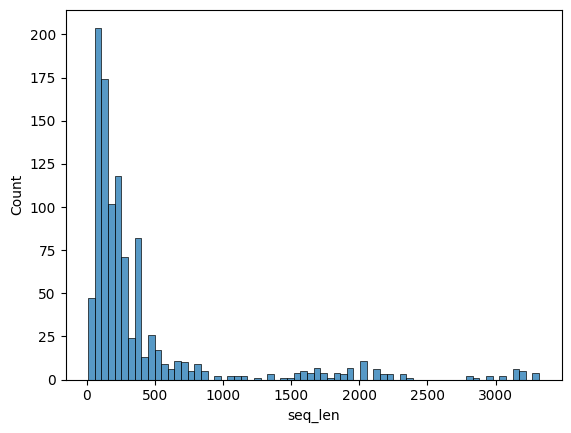

      start      end  count  percentage
0     11.00   286.75    700   67.632850
1    286.75   562.50    184   17.777778
2    562.50   838.25     44    4.251208
3    838.25  1114.00     10    0.966184
4   1114.00  1389.75      7    0.676329
5   1389.75  1665.50     15    1.449275
6   1665.50  1941.25     22    2.125604
7   1941.25  2217.00     27    2.608696
8   2217.00  2492.75      4    0.386473
9   2492.75  2768.50      0    0.000000
10  2768.50  3044.25      5    0.483092
11  3044.25  3320.00     17    1.642512


In [52]:
print_seq_len_histogram(seq_filter, 12)